In [12]:
# import libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [38]:
class Batsman(TypedDict):
    name: str
    runs: int
    balls: int
    fours: int 
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

### Functions

In [39]:
def calculate_sr(batsman: Batsman):
    runs = batsman['runs']
    balls = batsman['balls']

    sr = (runs / balls) * 100 if balls != 0 else 0.0
    return {'sr': sr}

In [40]:
def calculate_bpb(batsman: Batsman):
    balls = batsman['balls']
    fours = batsman['fours']
    sixes = batsman['sixes']

    boundaries = fours + sixes
    bpb = None if boundaries == 0 else balls / boundaries
    return {'bpb': bpb}

In [41]:
def calculate_boundary_percent(batsman: Batsman):
    runs = batsman['runs']
    fours = batsman['fours']
    sixes = batsman['sixes']

    boundary_runs = (fours * 4) + (sixes * 6)
    boundary_percent = (boundary_runs / runs) * 100 if runs != 0 else 0.0
    return {'boundary_percent': boundary_percent}

In [56]:
def summarize_batsman(batsman: Batsman):
    summary = (f"{batsman['name']} scored {batsman['runs']} runs off {batsman['balls']} balls, "
                           f"with a strike rate of {batsman['sr']:.2f}, "
                           f"balls per boundary of {batsman['bpb']}, "
                           f"and boundary percentage of {batsman['boundary_percent']:.2f}%.")
    return {'summary': summary}

### Graph and Nodes

In [57]:
graph = StateGraph(Batsman)

# nodes 
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summarize_batsman', summarize_batsman)

### edges

In [58]:
# edges 
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summarize_batsman')
graph.add_edge('calculate_bpb', 'summarize_batsman')
graph.add_edge('calculate_boundary_percent', 'summarize_batsman')

graph.add_edge('summarize_batsman', END)

In [59]:
workflow = graph.compile()

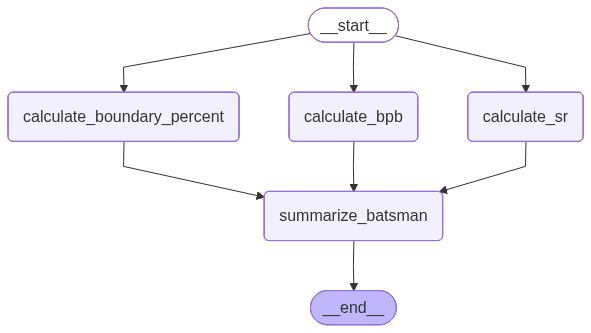

In [60]:
workflow

In [68]:
initial_state = {
    'name': 'Hasnain Yaqoob',
    'runs': 80,
    'balls': 50,
    'fours': 5,
    'sixes': 3
}

workflow.invoke({
    **initial_state,
})

{'name': 'Hasnain Yaqoob',
 'runs': 80,
 'balls': 50,
 'fours': 5,
 'sixes': 3,
 'sr': 160.0,
 'bpb': 6.25,
 'boundary_percent': 47.5,
 'summary': 'Hasnain Yaqoob scored 80 runs off 50 balls, with a strike rate of 160.00, balls per boundary of 6.25, and boundary percentage of 47.50%.'}